Импорты либ и настройка


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset, Dataset

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

import torch
import torch.nn as nn

from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import f1_score, accuracy_score

In [8]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [9]:
ds = load_dataset("Tobi-Bueck/customer-support-tickets")
df = ds["train"].to_pandas()

In [10]:
print(df.shape)
df.head()

(61765, 16)


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,None,None,None,None
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,None,None,None
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,None,None,None,None,None
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51.0,Billing,Payment,Account,Documentation,Feedback,None,None,None
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51.0,Product,Feature,Feedback,Tech Support,None,None,None,None


In [11]:
def read_idx(path):
    with open(path, "r") as f:
        return [int(x.strip()) for x in f.readlines()]

train_idx = read_idx("train_idx.txt")
val_idx = read_idx("val_idx.txt")
test_idx = read_idx("test_idx.txt")

In [12]:
train_df = df.iloc[train_idx].copy()
val_df = df.iloc[val_idx].copy()
test_df = df.iloc[test_idx].copy()

print(train_df.shape, val_df.shape, test_df.shape)

(49412, 16) (6176, 16) (6177, 16)


Оставим только нужные нам колонки

In [13]:
cols = [
    "subject",
    "body",
    "queue",
    "priority",
    "type"
]

train_df = train_df[cols].copy()
val_df = val_df[cols].copy()
test_df = test_df[cols].copy()

Выполняем базовую предобработку:

1. Пропуски в `subject` и `body` заменяются на пустые строки
2. Создаётся объединённый текстовый признак:

text = subject + [SEP] + body

3. Отсутствующие значения `type` заменяются на `Unknown`

In [14]:
for d in [train_df, val_df, test_df]:

    d["subject"] = d["subject"].fillna("")
    d["body"] = d["body"].fillna("")

    d["text"] = d["subject"] + " [SEP] " + d["body"]

    d["type"] = d["type"].fillna("Unknown")

In [15]:
train_df.head()

,subject,body,queue,priority,type,text
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Technical Support,high,Incident,Wesentlicher Sicherheitsvorfall [SEP] Sehr gee...
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...",Technical Support,high,Incident,Account Disruption [SEP] Dear Customer Support...
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Returns and Exchanges,medium,Request,Query About Smart Home System Integration Feat...
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",Billing and Payments,low,Request,Inquiry Regarding Invoice Details [SEP] Dear C...
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Sales and Pre-Sales,medium,Problem,Question About Marketing Agency Software Compa...


EDA

In [16]:
train_df.isna().sum()

,0
subject,0
body,0
queue,0
priority,0
type,0
text,0


In [17]:
queue_counts = train_df["queue"].value_counts()

print("Количество классов:", queue_counts.shape[0])

queue_counts.head(10)

Количество классов: 52


,count
queue,
Technical Support,11354
Product Support,7139
Customer Service,5905
IT Support,4673
Billing and Payments,3853
Returns and Exchanges,1956
Service Outages and Maintenance,1534
Sales and Pre-Sales,1228
Human Resources,730


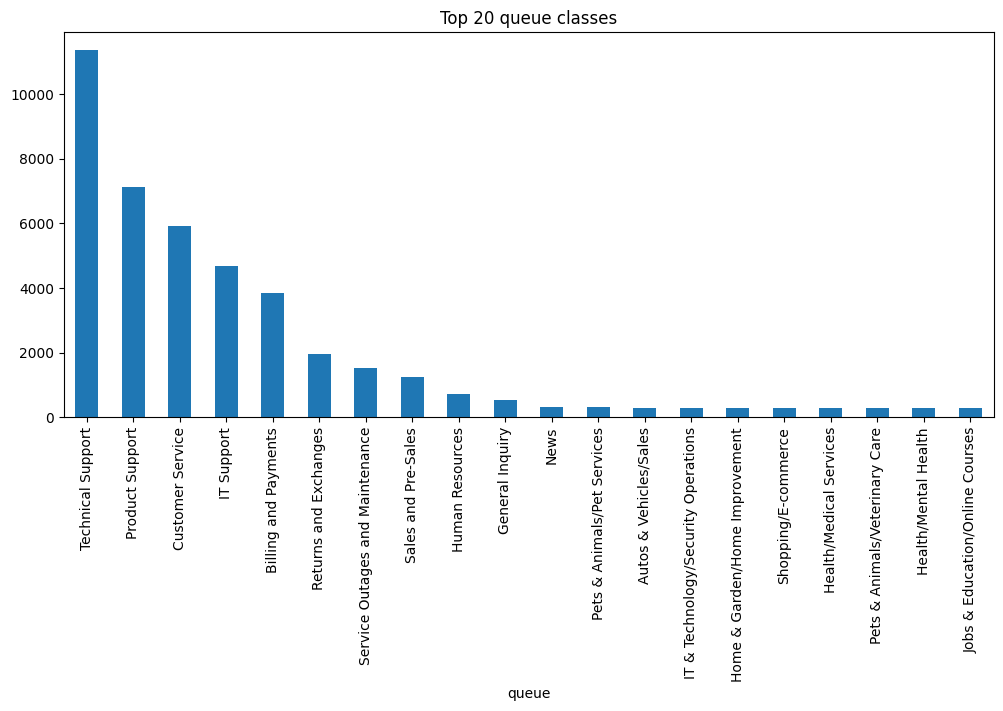

In [18]:
plt.figure(figsize=(12,5))

queue_counts.head(20).plot(kind="bar")

plt.title("Top 20 queue classes")

plt.show()

In [19]:
queue_counts.describe()

,count
count,52.000000
mean,950.230769
std,2056.279265
min,187.000000
25%,237.000000
50%,260.000000
75%,285.500000
max,11354.000000



Целевая переменная `queue` содержит 52 класса и характеризуется сильным дисбалансом.

Несколько категорий (например Technical Support, Product Support, Customer Service)
содержат значительно больше примеров, чем остальные.

Такой дисбаланс делает задачу сложнее, особенно при использовании метрики Macro-F1,
которая одинаково учитывает качество классификации для всех классов.

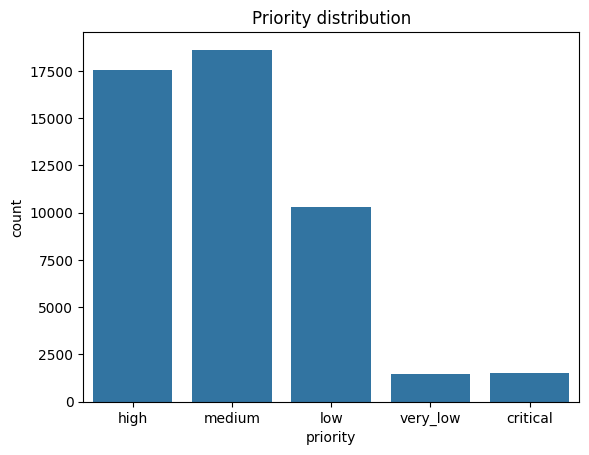

In [20]:
sns.countplot(data=train_df, x="priority")

plt.title("Priority distribution")

plt.show()

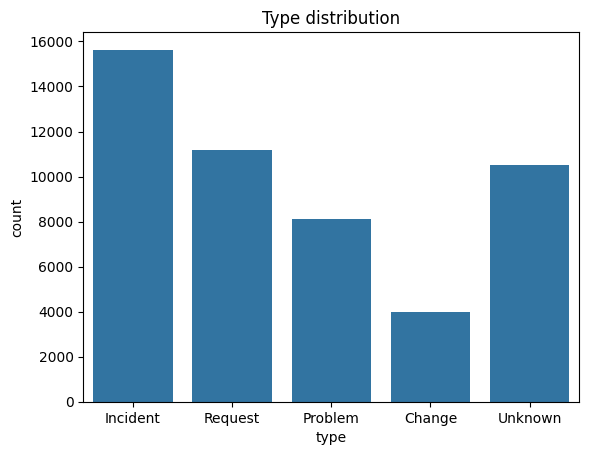

In [21]:
sns.countplot(data=train_df, x="type")

plt.title("Type distribution")

plt.show()

In [22]:
(train_df["type"] == "Unknown").mean()

np.float64(0.21266089209099004)

In [23]:
train_df["text_len"] = train_df["text"].str.len()

train_df["text_len"].describe()

,text_len
count,49412.000000
mean,469.754635
std,226.844163
min,11.000000
25%,285.000000
50%,465.000000
75%,639.000000
max,2290.000000


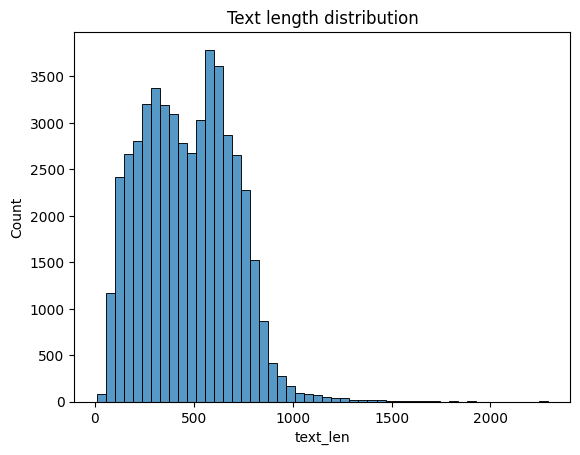

In [24]:
sns.histplot(train_df["text_len"], bins=50)

plt.title("Text length distribution")

plt.show()

In [25]:
train_df["tokens"] = train_df["text"].str.split().apply(len)

train_df["tokens"].describe()

,tokens
count,49412.000000
mean,63.445438
std,31.205693
min,2.000000
25%,38.000000
50%,63.000000
75%,88.000000
max,284.000000




Средняя длина тикета составляет около 63 токенов.

Большинство текстов относительно короткие, что делает возможным
использование ограниченной длины последовательности (например 128 токенов)
для трансформерных моделей.

In [26]:
for i in range(3):

    row = train_df.sample(1).iloc[0]

    print("QUEUE:", row["queue"])
    print("PRIORITY:", row["priority"])
    print("TYPE:", row["type"])

    print("\nSUBJECT:")
    print(row["subject"])

    print("\nBODY:")
    print(row["body"][:500])

    print("\n", "-"*80, "\n")

QUEUE: Billing and Payments
PRIORITY: medium
TYPE: Request

SUBJECT:
Support Details for Project Management SaaS

BODY:
Could you provide details on the billing process for our project management SaaS subscription? I would like to know the payment terms and any additional fees associated with it.

 -------------------------------------------------------------------------------- 

QUEUE: Product Support
PRIORITY: medium
TYPE: Incident

SUBJECT:
Bestätigung der Datenverletzung und Maßnahmen zur Verbesserung der IT-Sicherheit

BODY:
Es wurde eine Datenverletzung erkannt, die auf veraltete Software im medizinischen Akten-IT-System zurückzuführen ist, die Sicherheitspatches waren nicht angewendet. Diese Situation ist gravierend, insbesondere wenn medizinische Akten betroffen sind. Die bereits unternehmenen Maßnahmen umfassen die Aktualisierung der Antivirus-Software und das Überprüfen der Zugangssteuerungen. Obwohl diese Schritte in die richtige Richtung gehen, ist eine umfassende Anstrengu



Тексты тикетов содержат как английский, так и немецкий язык.
Поэтому для нейросетевой модели был выбран мультиязычный трансформер.

In [27]:
X_train = train_df["text"]
X_val = val_df["text"]

y_train = train_df["queue"]
y_val = val_df["queue"]

## Базовая модель (baseline)

В качестве базовой модели используется классический подход:

TF-IDF представление текста + линейный классификатор (LinearSVC).

Такие модели часто показывают сильные результаты в задачах
классификации коротких текстов.

In [87]:
tfidf = TfidfVectorizer(

    lowercase=True,

    ngram_range=(1,2),      # учитываем биграммы

    min_df=3,               # убираем редкие слова

    max_features=100000,

    sublinear_tf=True
)

In [88]:
X_train_tfidf = tfidf.fit_transform(X_train)

X_val_tfidf = tfidf.transform(X_val)

In [89]:
X_train_tfidf.shape

(49412, 100000)

In [90]:
model = LinearSVC(

    class_weight="balanced",   # важно из-за дисбаланса

    max_iter=5000
)

In [91]:
model.fit(X_train_tfidf, y_train)

LinearSVC(class_weight='balanced', max_iter=5000)

In [92]:
val_pred = model.predict(X_val_tfidf)

In [93]:
macro_f1 = f1_score(y_val, val_pred, average="macro")

acc = accuracy_score(y_val, val_pred)

print("Validation Macro-F1 (queue):", macro_f1)
print("Validation Accuracy (queue):", acc)

Validation Macro-F1 (queue): 0.875533851572103
Validation Accuracy (queue): 0.6387629533678757


In [94]:
print(classification_report(y_val, val_pred))

                                        precision    recall  f1-score   support

           Arts & Entertainment/Movies       0.97      0.97      0.97        29
            Arts & Entertainment/Music       0.91      0.94      0.92        31
          Autos & Vehicles/Maintenance       0.90      0.93      0.92        30
                Autos & Vehicles/Sales       0.97      0.95      0.96        39
            Beauty & Fitness/Cosmetics       0.96      1.00      0.98        26
     Beauty & Fitness/Fitness Training       1.00      1.00      1.00        23
                  Billing and Payments       0.75      0.75      0.75       489
            Books & Literature/Fiction       0.97      1.00      0.98        29
        Books & Literature/Non-Fiction       1.00      1.00      1.00        32
   Business & Industrial/Manufacturing       1.00      1.00      1.00        43
                      Customer Service       0.55      0.50      0.52       749
                   Finance/Investments 

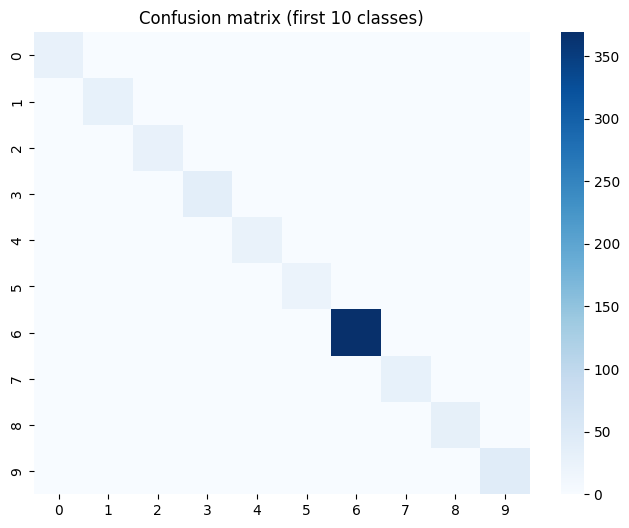

In [36]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, val_pred)

plt.figure(figsize=(8,6))

sns.heatmap(cm[:10,:10], cmap="Blues")

plt.title("Confusion matrix (first 10 classes)")
plt.show()


### Вывод

Baseline модель TF-IDF + LinearSVC показала достаточно высокий результат
по основной метрике Macro-F1.

Это означает, что для задачи маршрутизации тикетов
ключевые слова оказываются весьма информативными.

Дополнительно сравним два варианта TF-IDF представления:

- ngram_range = (1,2)
- ngram_range = (1,3)

Это позволит проверить, улучшают ли триграммы качество модели.

In [37]:
tfidf_13 = TfidfVectorizer(

    lowercase=True,

    ngram_range=(1,3),   # ← триграммы

    min_df=3,

    max_features=120000,

    sublinear_tf=True
)

In [38]:
X_train_tfidf_13 = tfidf_13.fit_transform(X_train)

X_val_tfidf_13 = tfidf_13.transform(X_val)

In [39]:
model_13 = LinearSVC(
    class_weight="balanced",
    max_iter=5000
)

model_13.fit(X_train_tfidf_13, y_train)

LinearSVC(class_weight='balanced', max_iter=5000)

In [40]:
pred_13 = model_13.predict(X_val_tfidf_13)

In [41]:
macro_f1_13 = f1_score(y_val, pred_13, average="macro")
acc_13 = accuracy_score(y_val, pred_13)

print("Macro F1:", macro_f1_13)
print("Accuracy:", acc_13)

Macro F1: 0.8644786581645538
Accuracy: 0.6382772020725389


In [42]:
baseline_results = pd.DataFrame({

    "model": [
        "TF-IDF + LinearSVC (1,2)",
        "TF-IDF + LinearSVC (1,3)"
    ],

    "MacroF1_queue": [
        macro_f1,
        macro_f1_13
    ],

    "Accuracy_queue": [
        acc,
        acc_13
    ]
})

baseline_results

,model,MacroF1_queue,Accuracy_queue
0,"TF-IDF + LinearSVC (1,2)",0.875534,0.638763
1,"TF-IDF + LinearSVC (1,3)",0.864479,0.638277


### Вывод

Использование n-грамм (1,2) показало лучший результат по основной метрике Macro-F1,
поэтому этот вариант был выбран как основной baseline.

## Transformer модель (single-task)

Далее обучим нейросетевую модель на основе трансформера.

Так как датасет содержит тексты на нескольких языках,
используется мультиязычная модель XLM-RoBERTa.

На данном этапе модель обучается только для предсказания `queue`.

In [43]:
queue_le = LabelEncoder()

train_df["queue_id"] = queue_le.fit_transform(train_df["queue"])
val_df["queue_id"] = queue_le.transform(val_df["queue"])
test_df["queue_id"] = queue_le.transform(test_df["queue"])

num_queue_labels = train_df["queue_id"].nunique()
print(num_queue_labels)

52


In [44]:
train_queue_ds = Dataset.from_pandas(
    train_df[["text", "queue_id"]].rename(columns={"queue_id": "label"}),
    preserve_index=False
)

val_queue_ds = Dataset.from_pandas(
    val_df[["text", "queue_id"]].rename(columns={"queue_id": "label"}),
    preserve_index=False
)

test_queue_ds = Dataset.from_pandas(
    test_df[["text", "queue_id"]].rename(columns={"queue_id": "label"}),
    preserve_index=False
)

In [45]:
MODEL_NAME = "xlm-roberta-base"
MAX_LEN = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [46]:
def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN
    )

train_queue_ds = train_queue_ds.map(tokenize_batch, batched=True)
val_queue_ds = val_queue_ds.map(tokenize_batch, batched=True)
test_queue_ds = test_queue_ds.map(tokenize_batch, batched=True)

Map:   0%|          | 0/49412 [00:00<?, ? examples/s]

Map:   0%|          | 0/6176 [00:00<?, ? examples/s]

Map:   0%|          | 0/6177 [00:00<?, ? examples/s]

In [47]:
train_queue_ds.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

val_queue_ds.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

test_queue_ds.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

In [48]:
def compute_metrics_queue(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    macro_f1 = f1_score(labels, preds, average="macro")
    acc = accuracy_score(labels, preds)

    return {
        "macro_f1": macro_f1,
        "accuracy": acc
    }

In [49]:
queue_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_queue_labels
)

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [50]:
training_args_queue = TrainingArguments(
    output_dir="./xlmr_queue",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    save_total_limit=1,
    report_to="none",
    seed=42
)

In [51]:
trainer_queue = Trainer(
    model=queue_model,
    args=training_args_queue,
    train_dataset=train_queue_ds,
    eval_dataset=val_queue_ds,
    processing_class=tokenizer,
    compute_metrics=compute_metrics_queue
)

In [52]:
trainer_queue.train()

Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,2.075374,1.550982,0.624806,0.495466
2,1.372878,1.297456,0.781040,0.558452


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=12354, training_loss=1.7241258366470373, metrics={'train_runtime': 3548.9914, 'train_samples_per_second': 27.846, 'train_steps_per_second': 3.481, 'total_flos': 6503339966914560.0, 'train_loss': 1.7241258366470373, 'epoch': 2.0})

In [53]:
queue_val_metrics = trainer_queue.evaluate(val_queue_ds)
queue_val_metrics

{'eval_loss': 1.2974563837051392,
 'eval_macro_f1': 0.7810397794462796,
 'eval_accuracy': 0.5584520725388601,
 'eval_runtime': 52.3313,
 'eval_samples_per_second': 118.017,
 'eval_steps_per_second': 7.376,
 'epoch': 2.0}

In [55]:
single_task_results = pd.DataFrame({
    "model": ["XLM-RoBERTa single-task queue"],
    "MacroF1_queue": [queue_val_metrics["eval_macro_f1"]],
    "Accuracy_queue": [queue_val_metrics["eval_accuracy"]]
})

all_results = pd.concat([baseline_results, single_task_results], ignore_index=True)
all_results

,model,MacroF1_queue,Accuracy_queue
0,"TF-IDF + LinearSVC (1,2)",0.875534,0.638763
1,"TF-IDF + LinearSVC (1,3)",0.864479,0.638277
2,XLM-RoBERTa single-task queue,0.781040,0.558452


### Вывод

Transformer модель показала более низкое качество,
чем baseline TF-IDF модель.

Это может быть связано с тем, что в данной задаче
ключевую роль играют явные лексические признаки,
которые хорошо извлекаются с помощью TF-IDF.

## Multitask transformer

Поскольку итоговая метрика задания учитывает не только `queue`,
но также `priority` и `type`,
обучим модель в режиме multi-task learning.

Модель будет одновременно предсказывать:

- queue
- priority
- type

In [56]:
le_queue = LabelEncoder()
le_priority = LabelEncoder()
le_type = LabelEncoder()

train_df["queue_id"] = le_queue.fit_transform(train_df["queue"])
val_df["queue_id"] = le_queue.transform(val_df["queue"])
test_df["queue_id"] = le_queue.transform(test_df["queue"])

train_df["priority_id"] = le_priority.fit_transform(train_df["priority"])
val_df["priority_id"] = le_priority.transform(val_df["priority"])
test_df["priority_id"] = le_priority.transform(test_df["priority"])

train_df["type_id"] = le_type.fit_transform(train_df["type"])
val_df["type_id"] = le_type.transform(val_df["type"])
test_df["type_id"] = le_type.transform(test_df["type"])

print(len(le_queue.classes_), len(le_priority.classes_), len(le_type.classes_))

52 5 5


In [57]:
train_mt_ds = Dataset.from_pandas(
    train_df[["text","queue_id","priority_id","type_id"]]
)

val_mt_ds = Dataset.from_pandas(
    val_df[["text","queue_id","priority_id","type_id"]]
)

test_mt_ds = Dataset.from_pandas(
    test_df[["text","queue_id","priority_id","type_id"]]
)

In [58]:
def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_mt_ds = train_mt_ds.map(tokenize_batch, batched=True)
val_mt_ds = val_mt_ds.map(tokenize_batch, batched=True)
test_mt_ds = test_mt_ds.map(tokenize_batch, batched=True)

Map:   0%|          | 0/49412 [00:00<?, ? examples/s]

Map:   0%|          | 0/6176 [00:00<?, ? examples/s]

Map:   0%|          | 0/6177 [00:00<?, ? examples/s]

In [59]:
train_mt_ds.set_format(
    type="torch",
    columns=["input_ids","attention_mask","queue_id","priority_id","type_id"]
)

val_mt_ds.set_format(
    type="torch",
    columns=["input_ids","attention_mask","queue_id","priority_id","type_id"]
)

test_mt_ds.set_format(
    type="torch",
    columns=["input_ids","attention_mask","queue_id","priority_id","type_id"]
)

In [60]:
from transformers import AutoModel

class MultiTaskModel(nn.Module):

    def __init__(self, model_name, n_queue, n_priority, n_type):
        super().__init__()

        self.encoder = AutoModel.from_pretrained(model_name)

        hidden = self.encoder.config.hidden_size

        self.queue_head = nn.Linear(hidden, n_queue)
        self.priority_head = nn.Linear(hidden, n_priority)
        self.type_head = nn.Linear(hidden, n_type)

    def forward(self, input_ids, attention_mask,
                queue_id=None, priority_id=None, type_id=None):

        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        pooled = outputs.last_hidden_state[:,0]

        queue_logits = self.queue_head(pooled)
        priority_logits = self.priority_head(pooled)
        type_logits = self.type_head(pooled)

        loss = None

        if queue_id is not None:
            loss_fct = nn.CrossEntropyLoss()

            loss_queue = loss_fct(queue_logits, queue_id)
            loss_priority = loss_fct(priority_logits, priority_id)
            loss_type = loss_fct(type_logits, type_id)

            loss = loss_queue + loss_priority + loss_type

        return {
            "loss": loss,
            "queue_logits": queue_logits,
            "priority_logits": priority_logits,
            "type_logits": type_logits
        }

In [61]:
model_mt = MultiTaskModel(
    model_name="xlm-roberta-base",
    n_queue=len(le_queue.classes_),
    n_priority=len(le_priority.classes_),
    n_type=len(le_type.classes_)
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [62]:
def compute_metrics_mt(eval_pred):

    logits = eval_pred.predictions

    queue_logits = logits[0]
    priority_logits = logits[1]
    type_logits = logits[2]

    labels_queue = eval_pred.label_ids[0]
    labels_priority = eval_pred.label_ids[1]
    labels_type = eval_pred.label_ids[2]

    pred_queue = queue_logits.argmax(axis=1)
    pred_priority = priority_logits.argmax(axis=1)
    pred_type = type_logits.argmax(axis=1)

    macro_f1 = f1_score(labels_queue, pred_queue, average="macro")

    acc_queue = accuracy_score(labels_queue, pred_queue)
    acc_priority = accuracy_score(labels_priority, pred_priority)
    acc_type = accuracy_score(labels_type, pred_type)

    return {
        "macro_f1_queue": macro_f1,
        "acc_queue": acc_queue,
        "acc_priority": acc_priority,
        "acc_type": acc_type
    }

In [65]:
training_args_mt = TrainingArguments(
    output_dir="mt_model",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    logging_steps=200
)

In [68]:
trainer_mt = Trainer(
    model=model_mt,
    args=training_args_mt,
    train_dataset=train_mt_ds,
    eval_dataset=val_mt_ds
)

trainer_mt.train()

Step,Training Loss
200,5.256654
400,4.207212
600,3.926195
800,3.781391
1000,3.632680
1200,3.554527
1400,3.556977
1600,3.550464
1800,3.485782
2000,3.481847


TrainOutput(global_step=12354, training_loss=2.8793703054212263, metrics={'train_runtime': 5400.2257, 'train_samples_per_second': 18.3, 'train_steps_per_second': 2.288, 'total_flos': 0.0, 'train_loss': 2.8793703054212263, 'epoch': 2.0})

In [70]:
mt_metrics = trainer_mt.evaluate(val_mt_ds)
mt_metrics

Step,Training Loss,Validation Loss
50,No log,No log


{}

In [72]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [75]:
pred = trainer_mt.predict(val_mt_ds)

Step,Training Loss,Validation Loss
50,No log,No log


In [82]:
queue_logits = pred.predictions[1]
priority_logits = pred.predictions[2]
type_logits = pred.predictions[3]

pred_queue = queue_logits.argmax(axis=1)
pred_priority = priority_logits.argmax(axis=1)
pred_type = type_logits.argmax(axis=1)

In [83]:
macro_f1_queue = f1_score(labels_queue, pred_queue, average="macro")

acc_queue = accuracy_score(labels_queue, pred_queue)
acc_priority = accuracy_score(labels_priority, pred_priority)
acc_type = accuracy_score(labels_type, pred_type)

print("MacroF1(queue):", macro_f1_queue)
print("Accuracy(queue):", acc_queue)
print("Accuracy(priority):", acc_priority)
print("Accuracy(type):", acc_type)

MacroF1(queue): 0.7630470940246901
Accuracy(queue): 0.5422603626943006
Accuracy(priority): 0.5816062176165803
Accuracy(type): 0.8646373056994818


In [84]:
score = (
    0.70 * macro_f1_queue
    + 0.15 * acc_priority
    + 0.15 * acc_type
)

print("Final score:", score)

Final score: 0.7510694943146923


### Вывод

Multitask transformer модель была обучена для одновременного
предсказания queue, priority и type.

Несмотря на использование современной архитектуры,
модель показала более низкое качество по основной задаче
маршрутизации (queue), чем baseline модель TF-IDF + LinearSVC.

Это может быть связано с тем, что тексты тикетов
часто содержат явные лексические признаки,
которые хорошо извлекаются классическими методами
представления текста.

Тем не менее multitask модель позволяет одновременно
предсказывать несколько характеристик тикета,
что может быть полезно для построения единой системы
автоматической обработки обращений.

In [99]:
pred_test_mt = trainer_mt.predict(test_mt_ds)

Step,Training Loss,Validation Loss
50,No log,No log


In [100]:
# Логиты по трём задачам
queue_logits_test = pred_test_mt.predictions[1]
priority_logits_test = pred_test_mt.predictions[2]
type_logits_test = pred_test_mt.predictions[3]

# Предсказанные классы
pred_queue_test = queue_logits_test.argmax(axis=1)
pred_priority_test = priority_logits_test.argmax(axis=1)
pred_type_test = type_logits_test.argmax(axis=1)

# Истинные метки
labels_queue_test = test_df["queue_id"].values
labels_priority_test = test_df["priority_id"].values
labels_type_test = test_df["type_id"].values

# Метрики
macro_f1_queue_test = f1_score(labels_queue_test, pred_queue_test, average="macro")
acc_queue_test = accuracy_score(labels_queue_test, pred_queue_test)
acc_priority_test = accuracy_score(labels_priority_test, pred_priority_test)
acc_type_test = accuracy_score(labels_type_test, pred_type_test)

print("Test MacroF1(queue):", macro_f1_queue_test)
print("Test Accuracy(queue):", acc_queue_test)
print("Test Accuracy(priority):", acc_priority_test)
print("Test Accuracy(type):", acc_type_test)

# Итоговый score
final_score_test = (
    0.70 * macro_f1_queue_test
    + 0.15 * acc_priority_test
    + 0.15 * acc_type_test
)

print("Test Final score:", final_score_test)

Test MacroF1(queue): 0.7621432996188713
Test Accuracy(queue): 0.5386109762020398
Test Accuracy(priority): 0.5617613728347094
Test Accuracy(type): 0.8599643840051805
Test Final score: 0.7467591732591934


In [101]:
X_test_tfidf = tfidf.transform(test_df["text"])
test_pred = model.predict(X_test_tfidf)

macro_f1_test = f1_score(test_df["queue"], test_pred, average="macro")
acc_test = accuracy_score(test_df["queue"], test_pred)

print("Baseline Test MacroF1(queue):", macro_f1_test)
print("Baseline Test Accuracy(queue):", acc_test)

Baseline Test MacroF1(queue): 0.8711246627818804
Baseline Test Accuracy(queue): 0.6435162700339971


In [102]:
results = pd.DataFrame({
    "model": [
        "TF-IDF + LinearSVC",
        "XLM-RoBERTa single-task",
        "XLM-RoBERTa multitask"
    ],
    "MacroF1_queue": [
        macro_f1_test,
        queue_val_metrics["eval_macro_f1"],
        macro_f1_queue
    ],
    "Accuracy_queue": [
        acc_test,
        queue_val_metrics["eval_accuracy"],
        acc_queue
    ]
})

results

,model,MacroF1_queue,Accuracy_queue
0,TF-IDF + LinearSVC,0.871125,0.643516
1,XLM-RoBERTa single-task,0.781040,0.558452
2,XLM-RoBERTa multitask,0.763047,0.542260


In [104]:
probs = torch.softmax(torch.tensor(queue_logits_test), dim=1).numpy()
confidence = probs.max(axis=1)

coverage_levels = [1.0, 0.9, 0.8, 0.7]

results = []

for c in coverage_levels:

    threshold = np.quantile(confidence, 1 - c)

    mask = confidence >= threshold

    f1 = f1_score(labels_queue_test[mask], pred_queue_test[mask], average="macro")

    results.append((c, f1))

confidence_results = pd.DataFrame(results, columns=["coverage","MacroF1"])

confidence_results

,coverage,MacroF1
0,1.0,0.762143
1,0.9,0.786226
2,0.8,0.793010
3,0.7,0.803272


### Вывод

Анализ уверенности модели показывает,
что качество классификации возрастает,
если учитывать только наиболее уверенные предсказания.

Например:

- при использовании всех предсказаний (coverage = 100%)
Macro-F1(queue) составляет 0.762

- если автоматически обрабатывать только 70% наиболее
уверенных тикетов, Macro-F1 возрастает до 0.803.

Это означает, что в реальной системе можно использовать
гибридный подход:

- уверенные предсказания обрабатываются автоматически
- сложные случаи передаются на ручную обработку.

Такой подход позволяет повысить качество автоматической
маршрутизации обращений.

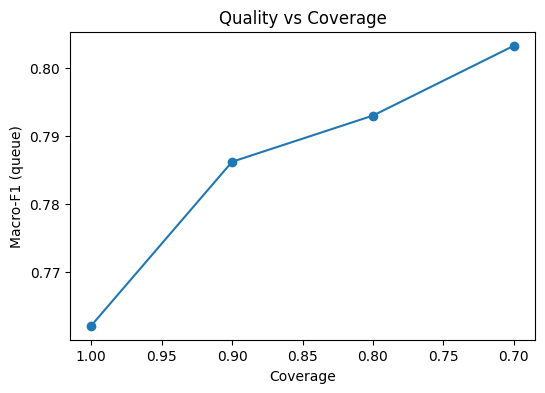

In [105]:
plt.figure(figsize=(6,4))

plt.plot(confidence_results["coverage"],
         confidence_results["MacroF1"],
         marker="o")

plt.gca().invert_xaxis()

plt.xlabel("Coverage")
plt.ylabel("Macro-F1 (queue)")

plt.title("Quality vs Coverage")

plt.show()